In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [2]:
df = pd.read_csv('Fertilizer Prediction.csv')

In [3]:
df.head()

,Temparature,Humidity,Moisture,Soil Type,Crop Type,Nitrogen,Potassium,Phosphorous,Fertilizer Name
0,32,51,41,Red,Ground Nuts,7,3,19,14-35-14
1,35,58,35,Black,Cotton,4,14,16,Urea
2,27,55,43,Sandy,Sugarcane,28,0,17,20-20
3,33,56,56,Loamy,Ground Nuts,37,5,24,28-28
4,32,70,60,Red,Ground Nuts,4,6,9,14-35-14


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   Temparature      100000 non-null  int64 
 1   Humidity         100000 non-null  int64 
 2   Moisture         100000 non-null  int64 
 3   Soil Type        100000 non-null  object
 4   Crop Type        100000 non-null  object
 5   Nitrogen         100000 non-null  int64 
 6   Potassium        100000 non-null  int64 
 7   Phosphorous      100000 non-null  int64 
 8   Fertilizer Name  100000 non-null  object
dtypes: int64(6), object(3)
memory usage: 6.9+ MB


In [5]:
df.describe()

,Temparature,Humidity,Moisture,Nitrogen,Potassium,Phosphorous
count,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.00000
mean,31.503300,60.985810,45.00344,22.986770,9.472220,21.01348
std,4.019942,6.651393,11.83871,11.247289,5.768565,12.39118
min,25.000000,50.000000,25.00000,4.000000,0.000000,0.00000
25%,28.000000,55.000000,35.00000,13.000000,4.000000,10.00000
50%,32.000000,61.000000,45.00000,23.000000,9.000000,21.00000
75%,35.000000,67.000000,55.00000,33.000000,14.000000,32.00000
max,38.000000,72.000000,65.00000,42.000000,19.000000,42.00000


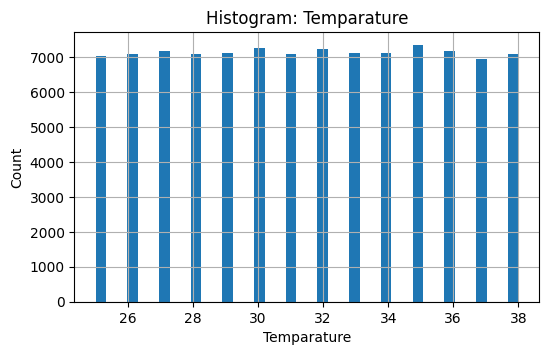

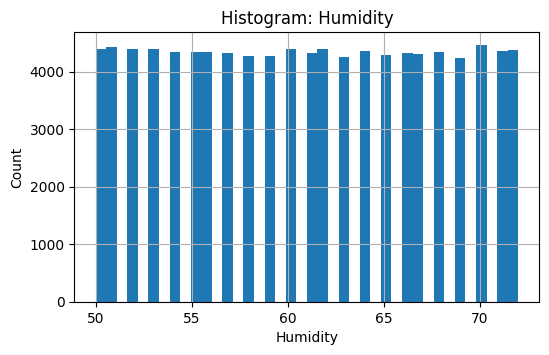

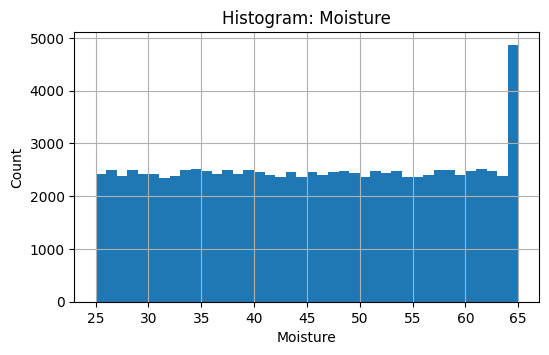

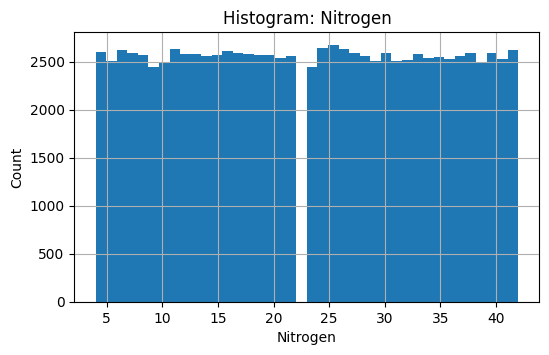

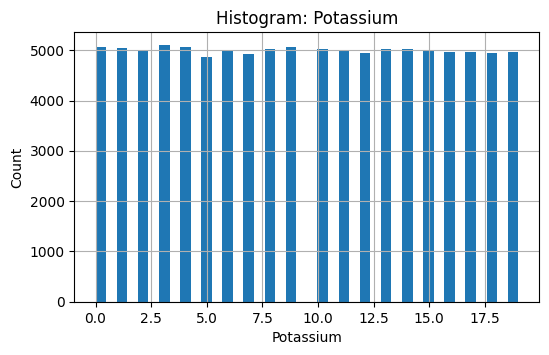

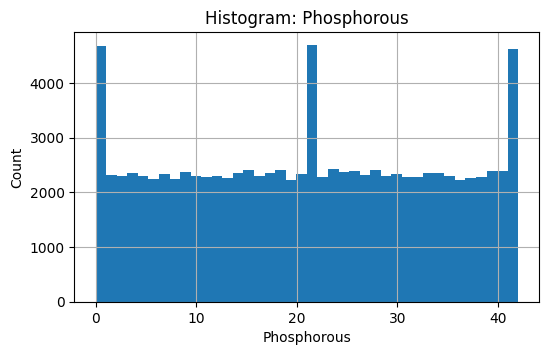

In [6]:
numeric_cols = ['Temparature','Humidity','Moisture','Nitrogen','Potassium','Phosphorous']
for col in numeric_cols:
    plt.figure(figsize=(6,3.5))
    plt.hist(df[col].dropna(), bins=40)
    plt.title(f'Histogram: {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.grid(True)
    plt.show()

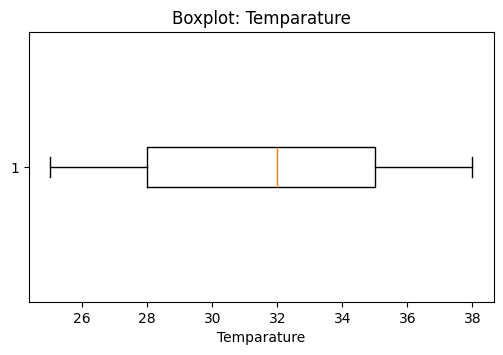

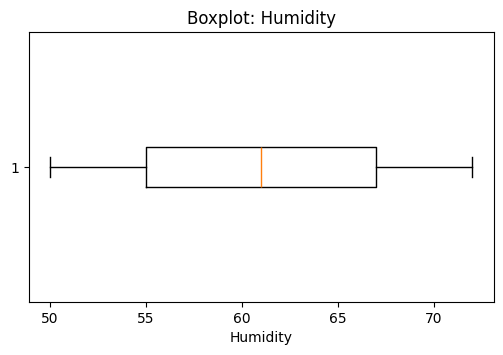

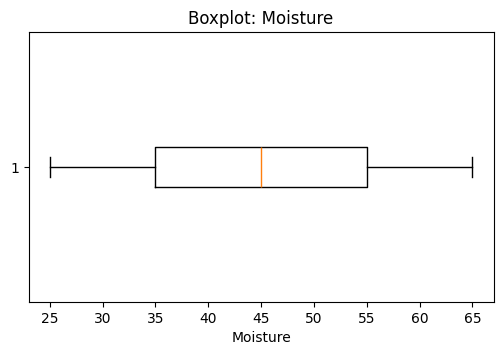

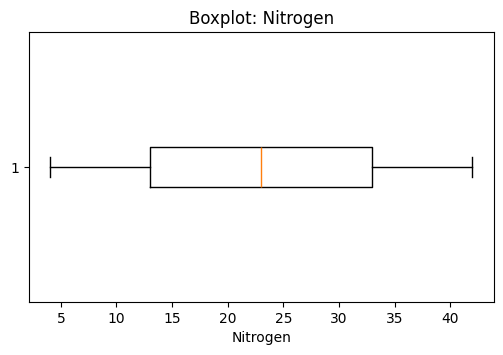

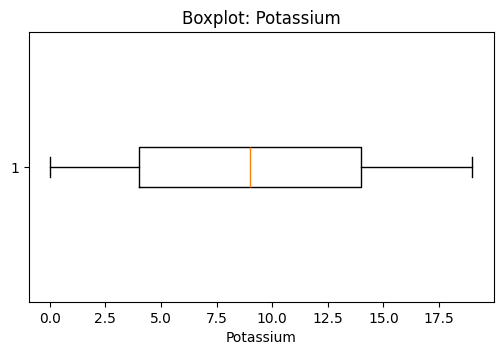

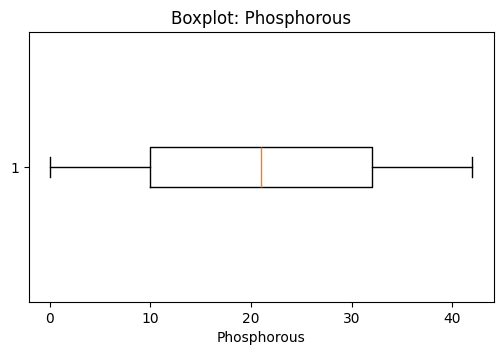

In [7]:
# 2) Boxplots to inspect outliers
for col in numeric_cols:
    plt.figure(figsize=(6,3.5))
    plt.boxplot(df[col].dropna(), vert=False)
    plt.title(f'Boxplot: {col}')
    plt.xlabel(col)
    plt.show()

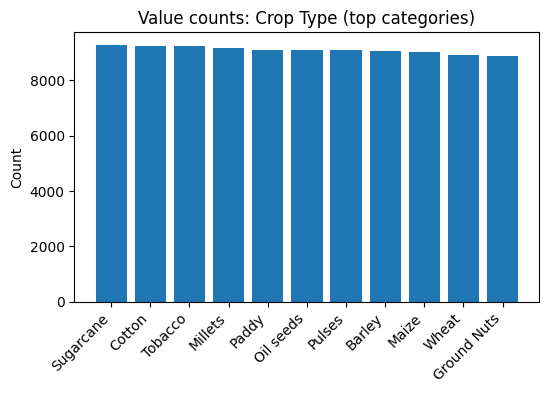

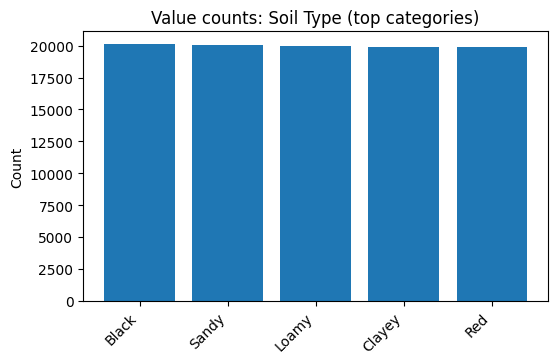

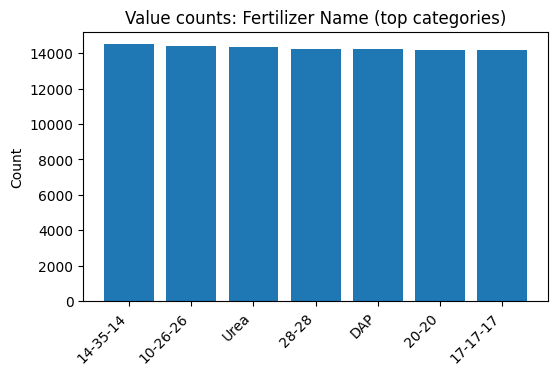

In [8]:
# 3) Categorical distributions (Crop Type, Soil Type, Fertilizer Name)
for col in ['Crop Type','Soil Type','Fertilizer Name']:
    vc = df[col].value_counts()
    plt.figure(figsize=(6,3.5))
    plt.bar(vc.index.astype(str), vc.values)
    plt.title(f'Value counts: {col} (top categories)')
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.show()

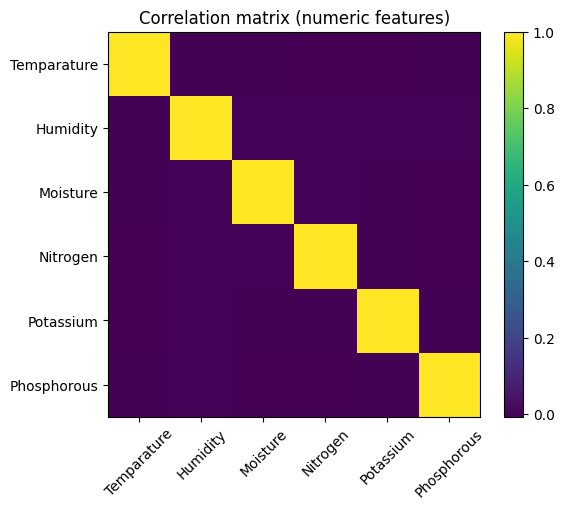

In [9]:
# 4) Correlation matrix heatmap (numeric)
corr = df[numeric_cols].corr()
plt.figure(figsize=(6,5))
plt.imshow(corr, interpolation='nearest', aspect='auto')
plt.title("Correlation matrix (numeric features)")
plt.colorbar()
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45)
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.show()

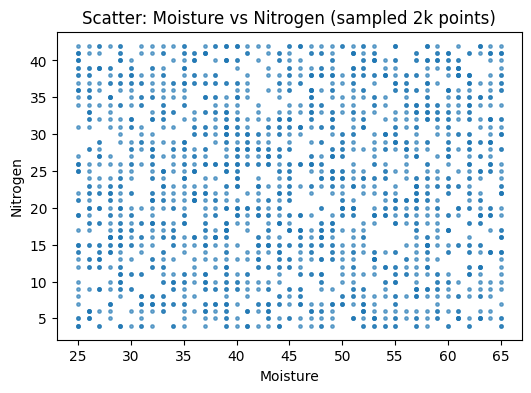

In [10]:
# 5) Scatter: Moisture vs Nitrogen to see relationships / clusters
plt.figure(figsize=(6,4))
mask = ~df['Moisture'].isna() & ~df['Nitrogen'].isna()
plt.scatter(df.loc[mask, 'Moisture'].sample(2000, random_state=1),
            df.loc[mask, 'Nitrogen'].sample(2000, random_state=1),
            s=6, alpha=0.6)
plt.xlabel('Moisture')
plt.ylabel('Nitrogen')
plt.title('Scatter: Moisture vs Nitrogen (sampled 2k points)')
plt.show()